<a href="https://colab.research.google.com/github/nathanellsley-del/Hist1354_Digital_Methods_Final/blob/main/Milestone_3_%26_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ****Final Project: Looking at the Relationship Between A State's Percentage of People Who had a Bachelor's Degree or Higher and the Median Personal Income By Examining the Vietnam Veteran Population From Each State****

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries have successfully been imported')

Libraries have successfully been imported


**Uploading The Data And Creating The Dataframe**

I uploaded the .csv file into Google Colab and copied its path into the code. The data was formed such that the titles for all the variables are written on the second line of cells in the .csv so in order for the program to understand the title I was referring to, I had to direct the code to look for the headers in line 1.

The .csv file likewise did not have a title for the column that listed each state, so I renamed the "Unnamed: 0" column to "State" for future reference in the code. After doing that, I deleted all the columns not related to the three variables I was tracking: the state the data is being reported from, median personal income of the veterans, and the percentage of veterans who held a Bachelor's Degree or higher.

Lastly, following the feedback I received from my milestone 3, I removed Puerto Rico from the data frame as it was an outlier whose special circumstances created a skew in the data visualization.

To ensure the code was executed properly, I had the code print that it worked.

In [58]:
file_path = ('/content/HIST_1534_Dataset_Vietnam_Veterans_by_State.csv')
df = pd.read_csv(file_path, header=1)

df = df.rename(columns={'Unnamed: 0': 'State'})
df = df[df["State"] != "Puerto Rico"]
df.to_csv("df_without_Puerto_Rico.csv", index=False)
df = df[["State", "Median Personal Income", "Bachelor's Degree or Higher"]]

print('worked')

worked


**Cleaning The Dataframe**

Next, I asked the program to tell me how many datapoints were missing in each of the columns. Then I went through the datapoints and cleaned all the data that was incomplete, such as changing some formats so that the program would be able to read it.

After doing that for both the columns for the datapoints I was observing, I created the new variable "clean_df" which encompassed all the cleaned data.

In [59]:
missing_data = df.isnull().sum()
print(missing_data)

filtered_out_rows = df.dropna(subset=["Bachelor's Degree or Higher"])
len(df)

clean_df = filtered_out_rows.copy()

clean_df["Median Personal Income"] = clean_df["Median Personal Income"].str.replace(',', '', regex=False)
clean_df["Median Personal Income"] = pd.to_numeric(clean_df["Median Personal Income"], errors='coerce')

clean_df["Bachelor's Degree or Higher"] = clean_df["Bachelor's Degree or Higher"].replace('▪', np.nan, regex=False)
clean_df["Bachelor's Degree or Higher"] = pd.to_numeric(clean_df["Bachelor's Degree or Higher"], errors='coerce')

clean_df = clean_df.dropna(subset=["Median Personal Income", "Bachelor's Degree or Higher"])

correlation = clean_df["Median Personal Income"].corr(clean_df["Bachelor's Degree or Higher"])

print(f'The correlation between Median Personal Income and Bachelor\'s Degree or Higher is: {correlation:.2f}')
print('done')

State                          2
Median Personal Income         8
Bachelor's Degree or Higher    8
dtype: int64
The correlation between Median Personal Income and Bachelor's Degree or Higher is: 0.67
done


**My First Visualization**

I decided to use the package matplotlib.pyplot for my first attempt to create a visualization because it was what I was used to using.

To label each data point, I implemented an index-based for loop that iterates through each row of the dataset. Within this loop, and referencing the syntax recommendations of generative AI, I used positional indexing (.iloc) to access the values for each state and placed a text label directly on the plot at the corresponding coordinates.

After plotting the data, I added a title and labeled both axes to provide context for the viewer.

When the initial output appeared cluttered and difficult to read due to overlapping labels, I adjusted the figure size and font size from 10 to 20 in an attempt to improve clarity and overall presentation, but I still wasn't happy with the way the data was presented.

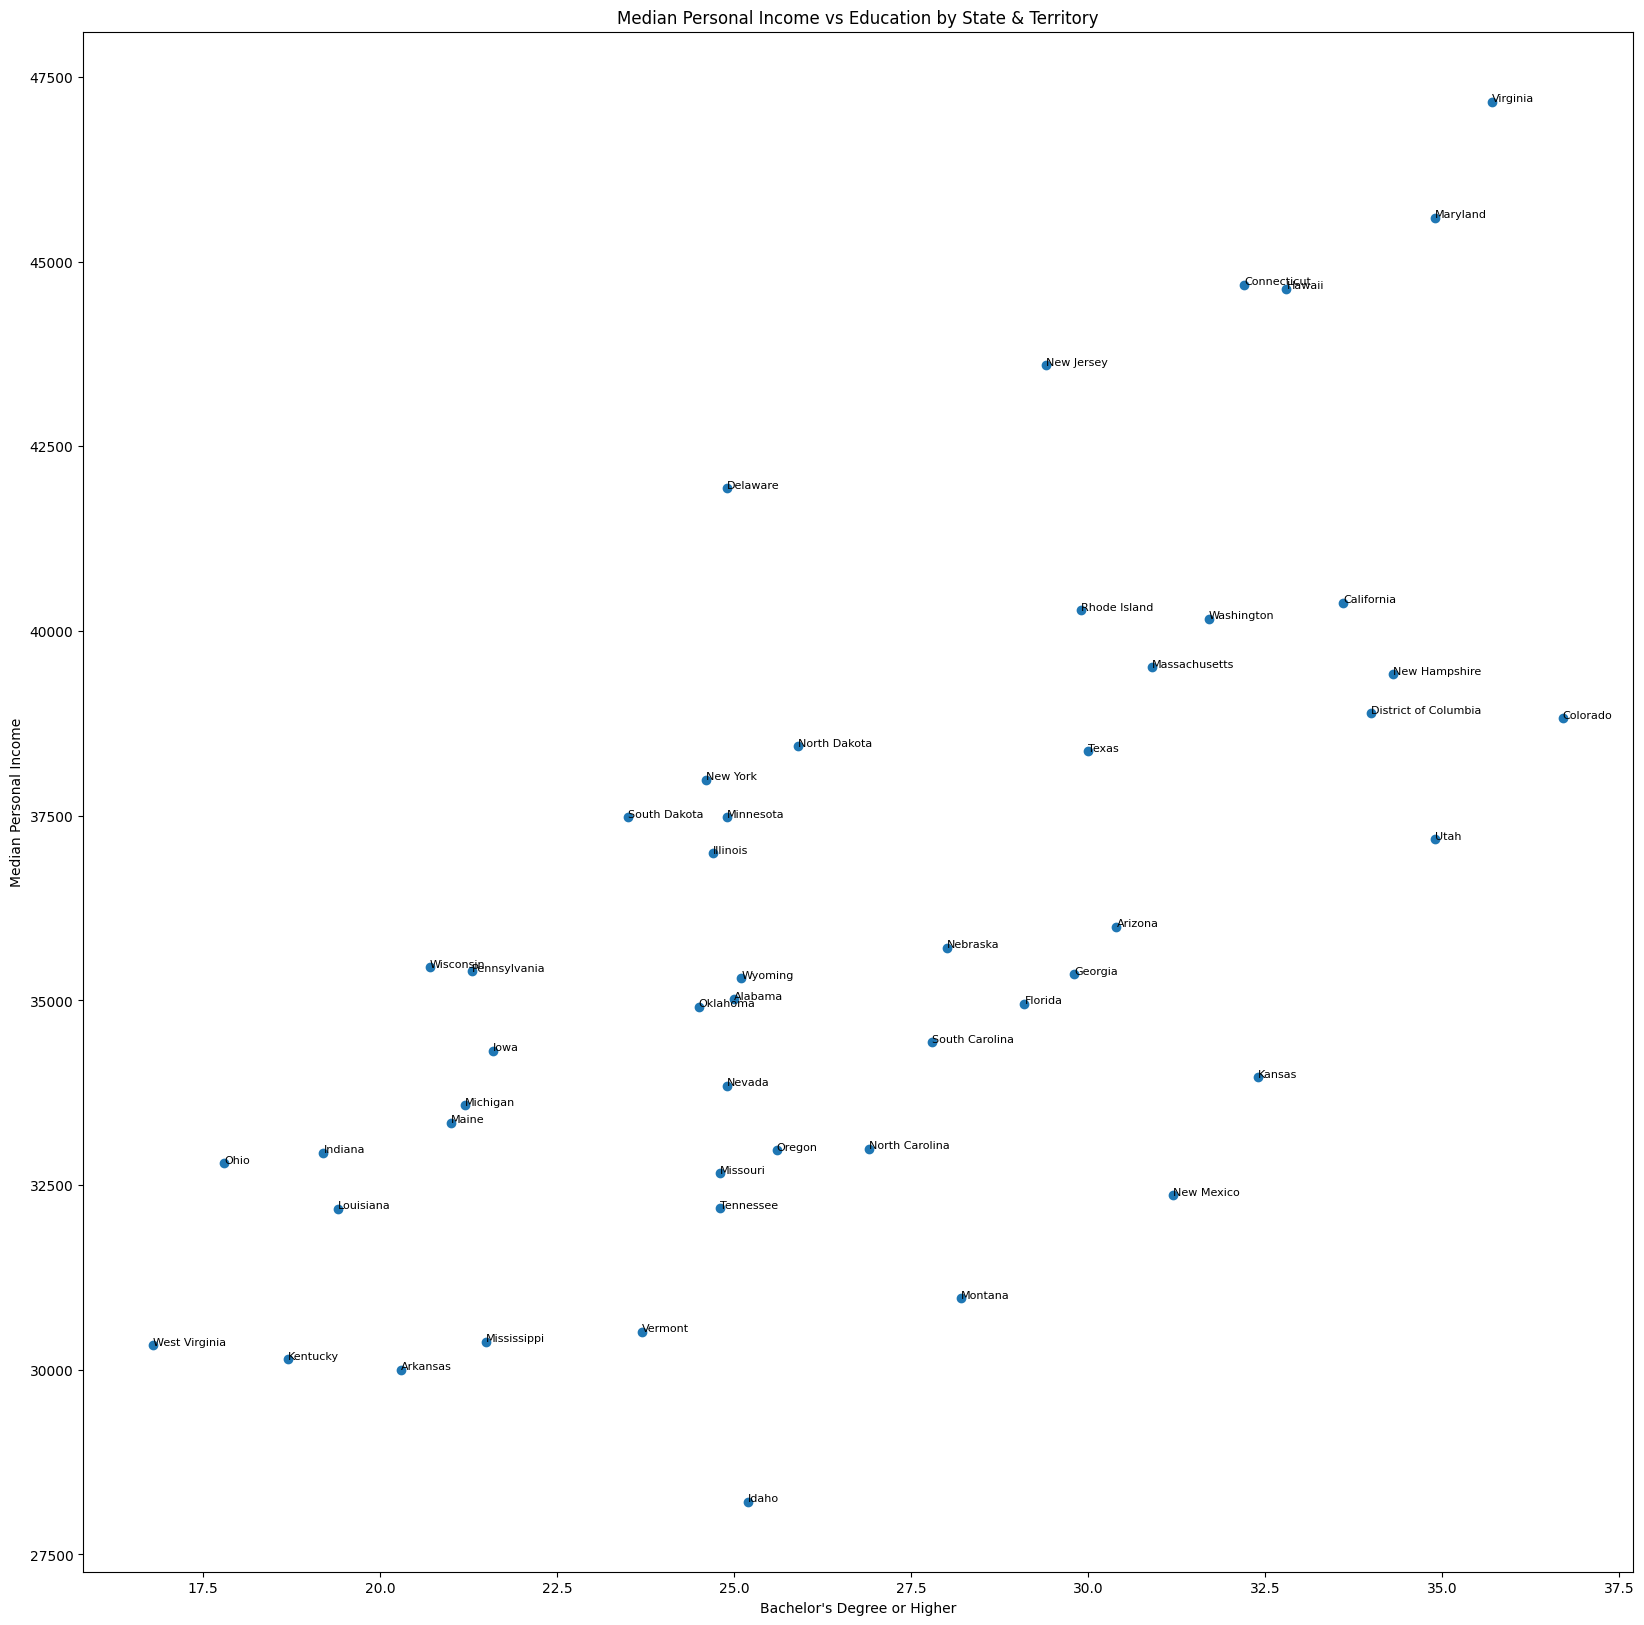

In [60]:
plt.figure(figsize=(20,20))
plt.scatter(clean_df["Bachelor's Degree or Higher"], clean_df["Median Personal Income"])
for state in range(len(clean_df)):
    plt.text(
        clean_df["Bachelor's Degree or Higher"].iloc[state],
        clean_df["Median Personal Income"].iloc[state],
        clean_df["State"].iloc[state],
        fontsize=8
    )
plt.xlabel("Bachelor's Degree or Higher")
plt.ylabel("Median Personal Income")
plt.title("Median Personal Income vs Education by State & Territory")

plt.show()

**My Second Visualization**

After realizing the limitations of matplotlib.pyplot, I decided to source a new package to better display my data. Using the reccomendation of generative AI, I adopted plotly.express as my data visualization tool. At the same time,I also decided to remove Peurto Rico from the dataset as it was an outlier that was skewing that data.

First I imported plotly.express. Next I used the guidance of generative AI to give me the syntax to direct the package to create a scatterplot using the cleaned dataframe, telling the program which variable should correspond to each axis.

Next I directed the program how I wanted to display the data, including how the hover function would work.

Lastly I the costumized layout by deciding the height, width, and axes titles.

When I was done, I had the program show me the visualzation.

In [61]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Bachelor's Degree or Higher",
    y="Median Personal Income",
    text="State",
    title="Median Personal Income vs Education by State"
)

fig.update_traces(
    marker=dict(size=10, color='blue'),
    selector=dict(mode='markers+text')
)

fig.update_layout(
    width=1000,
    height=500,
    hovermode="closest",
    xaxis_title="Percent of Service Members with Bachelor's Degree or Higher",
    yaxis_title="Median Personal Income in USD"
)

fig.show()

# ****Adding Another Variable - The Veitnam Veteran Population of Each State****

To add depth to my research project, I decided I wanted to consider the state's Vietnam Veteran population. My goal was to see whether there was a measurable difference in the relationship between the ratio of a state's education level and median personal income and the number of veterans each state sent to Vietnam.

To incorporate another variable, I reuploaded the dataset and this time expanded the data frame to include the state name, median personal income, bachelor's degree or higher, and now also the Vietnam veteran population.

I likewise set the conditions of the data table to read the state's name properly and also removed Puerto Rico from the dataset.

I then printed the first five lines of data to ensure the code properly produced the table with the variables I was analyzing.

In [62]:
file_path_original = '/content/HIST_1534_Dataset_Vietnam_Veterans_by_State.csv'
df_full = pd.read_csv(file_path_original, header=1)
df_full = df_full.rename(columns={'Unnamed: 0': 'State'})

df = df_full[["State", "Vietnam Veteran Population", "Median Personal Income", "Bachelor's Degree or Higher"]].copy()

df["State"] = df["State"].str.strip()
df = df[df["State"] != "Puerto Rico"]

df.head(5)

,State,Vietnam Veteran Population,Median Personal Income,Bachelor's Degree or Higher
0,Alabama,"121,206","35,017",25
1,Alaska,"18,200","49,174",▪
2,Arizona,"171,498","35,996",30.4
3,Arkansas,"71,133","30,003",20.3
4,California,"590,415","40,381",33.6


**Create a ratio for the two variables**

Before I could compare the states' education and income levels to the veteran population, I first had to create a ratio between the percentage of veterans with a bachelor's degree and the median personal income.

I started by cleaning the data, ensuring that all the datapoints were integers. To do this I had the code identify the type of each cell, and then if the datapoint was a string it would remove all the commas and/or blank values and then convert it to numeric. I did this for both the "Median Personal Income" and "Bachelor's Degree or Higher" variables. Next, I directed the code to drop any incomplete rows.

Lastly, I created a new column for the ratio and then told the program to print the data frame so I could ensure everything corresponded correctly.

In [63]:
if df["Median Personal Income"].dtype == 'object':
    df["Median Personal Income"] = df["Median Personal Income"].str.replace(',', '', regex=False)
df["Median Personal Income"] = pd.to_numeric(df["Median Personal Income"], errors='coerce')

if df["Bachelor's Degree or Higher"].dtype == 'object':
    df["Bachelor's Degree or Higher"] = df["Bachelor's Degree or Higher"].replace('▪', np.nan, regex=False)
df["Bachelor's Degree or Higher"] = pd.to_numeric(df["Bachelor's Degree or Higher"], errors='coerce')

df.dropna(subset=["Median Personal Income", "Bachelor's Degree or Higher"], inplace=True)

df["Income_Education_Ratio"] = df["Median Personal Income"] / df["Bachelor's Degree or Higher"]

print(df[["State", "Income_Education_Ratio"]])

                   State  Income_Education_Ratio
0                Alabama             1400.680000
2                Arizona             1184.078947
3               Arkansas             1477.980296
4             California             1201.815476
5               Colorado             1057.683924
6            Connecticut             1387.795031
7               Delaware             1684.176707
8   District of Columbia             1143.647059
9                Florida             1201.305842
10               Georgia             1186.409396
11                Hawaii             1360.731707
12                 Idaho             1119.603175
13              Illinois             1497.813765
14               Indiana             1715.625000
15                  Iowa             1588.750000
16                Kansas             1048.271605
17              Kentucky             1611.978610
18             Louisiana             1658.762887
19                 Maine             1587.952381
20              Mary

**Data Cleaning pt. 2**

Now that I had each states' ratio for the correlation between income and education, I had to link it to the Vietnam veteran population from each state.

Like in the previous cell, I directed the code to identify the type of each datapoint and if it was anything other than an integer to clean and convert it. I then told the code to drop any null data.

Finally, I found the numerical ratio for each state income and education levels to the veteran populations by dividing the income and education ratio to the Vietnam veteran population thus giving me a quantifiable measure of how the amount of veterans from each state weighs on the income and education levels of the veterans.

I then told the code display this new table.

In [64]:
if df['Vietnam Veteran Population'].dtype == 'object':
    df['Vietnam Veteran Population'] = df['Vietnam Veteran Population'].str.replace(',', '', regex=False)
df['Vietnam Veteran Population'] = pd.to_numeric(df['Vietnam Veteran Population'], errors='coerce')

df.dropna(subset=['Vietnam Veteran Population'], inplace=True)

df["Income_and_Education_to_Veteran_Population_Ratio"] = df["Income_Education_Ratio"] / df['Vietnam Veteran Population']

df.head()

,State,Vietnam Veteran Population,Median Personal Income,Bachelor's Degree or Higher,Income_Education_Ratio,Income_and_Education_to_Veteran_Population_Ratio
0,Alabama,121206,35017.0,25.0,1400.680000,0.011556
2,Arizona,171498,35996.0,30.4,1184.078947,0.006904
3,Arkansas,71133,30003.0,20.3,1477.980296,0.020778
4,California,590415,40381.0,33.6,1201.815476,0.002036
5,Colorado,127217,38817.0,36.7,1057.683924,0.008314


**Displaying the data visually**

Seeing how well the plotly visualized the income vs education levels, I decided I would use the same package to display the income/education vs veteran population graph. The further to the right a state was on the x-axis meant that that state had a high education to income ratio. The higher the state was on the y-axis meant that that state had a high Vietnam Veteran Population.

In [65]:
fig = px.scatter(
    df,
    x="Income_Education_Ratio",
    y="Vietnam Veteran Population",
    text="State",
    title="Income and Education Ratio to Veteran Population"
)

fig.update_traces(
    marker=dict(size=10, color='blue'),
    selector=dict(mode='markers+text')
)

fig.update_layout(
    width=1000,
    height=500,
    hovermode="closest",
    xaxis_title="Ratio of Those With a Bachelor's Degree and the Median Personal Income of Vietnam Veterans from that State",
    yaxis_title="Number of Vietnam Veterans"
)

fig.show()

# **Evaluating the Vietnam Veteran Population in the Context of the Overall State Population**

Naturally, states with large populations such as California, Florida, and Texas found their way to the top of the chart. To account for this, I decided to convert the variable of Vietnam Veteran population from a count to proportion.

I first found and downloaded the census data of population growth from the census website. I uploaded that file to Colab and told the code to read it. Next, I narrowed the data frame to only include the data from the years 1960 1970, the two years which most of the Vietnam War fell into.

I then cleaned the data by writing a loop that sifts through both columns removing blank spaces, unnecessary commas, and converting the values to integers.

Lastly, to get the average population of each state during the Vietnam War, I added the values of each states' population in 1960 and 1970 and then divided it by two. I then told to the code to display the table to ensure all the data I was analyzing computed properly.

In [66]:
file_path = '/content/1970_Census_Population_By_State(Sheet1).csv'
state_populations = pd.read_csv(file_path)

state_populations = state_populations[
    ["State", "Population as of 1970 census", "Population as of 1960 census"]
]

state_populations["State"] = state_populations["State"].str.strip() # Strip whitespace from 'State' column
for col in ["Population as of 1970 census", "Population as of 1960 census"]:
    state_populations[col] = state_populations[col].str.replace(",", "", regex=False)
    state_populations[col] = pd.to_numeric(state_populations[col], errors="coerce")

state_populations["Average Population (1960-1970)"] = (
    state_populations["Population as of 1970 census"] +
    state_populations["Population as of 1960 census"]
) / 2

state_populations.head(5)

,State,Population as of 1970 census,Population as of 1960 census,Average Population (1960-1970)
0,California,19953134,15717204,17835169.0
1,New York,18236967,16782304,17509635.5
2,Pennsylvania,11793909,11319366,11556637.5
3,Texas,11196730,9579677,10388203.5
4,Illinois,11113976,10081158,10597567.0


Now that I have the average population of each state during the Vietnam War, I can merge the two datapoints to create one variable.

Using the help of generative AI to form the correct syntax, I merged the two datasets, specifically directing the code which rows and columns I wanted to be extracted and the way I wanted them to be matched. Then to create the proportion I was looking for, I created a new variable that divided the Vietnam Veteran Population over the Average State Population I previously calculated. I then had the code display the first five lines to ensure everything aligned properly.

In [67]:
merged_df = pd.merge(
    df,
    state_populations[["State", "Average Population (1960-1970)"]],
    on="State",
    how="inner"
)
merged_df["Proportion_of_Vietnam_Vet_Population"] = (
    merged_df["Vietnam Veteran Population"] /
    merged_df["Average Population (1960-1970)"]
)

merged_df["Proportion_of_Vietnam_Vet_Population"].head(5)

,Proportion_of_Vietnam_Vet_Population
0,0.036122
1,0.112528
2,0.038351
3,0.033104
4,0.064231


Finally, I could create the visualization that plots the ratio between education and income levels on the a-axis and the proportion of Vietnam veterans to the state population on the y-axis.

In [68]:
fig = px.scatter(
    merged_df,
    x="Income_and_Education_to_Veteran_Population_Ratio",
    y="Proportion_of_Vietnam_Vet_Population",
    text="State",
    title="Vietnam Veterans Proportion vs Income-Education Ratio"
)

fig.update_traces(
    marker=dict(size=10, color='blue'),
    selector=dict(mode='markers+text')
)

fig.update_layout(
    width=1000,
    height=500,
    hovermode="closest",
    xaxis_title="Income & Education to Veteran Population Ratio",
    yaxis=dict(
      title="Percentage of State Population that are Vietnam Veterans",
      tickformat=".0%"
    )
)

fig.show()